In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
#Built_ML model that predict charges if input are gaven

In [21]:
df=pd.read_csv('/content/new_insurance_data (1) (1).csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [22]:
#EDA
#clean null
#clean duplicate
#outlyers
#label encoding


In [23]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [24]:
for col in df.columns:
  if df[col].dtype =='object':
    df[col]=df[col].fillna(df[col].mode()[0])
  else:
    df[col]=df[col].fillna(df[col].mean())
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
#df.drop_duplicates().sum()

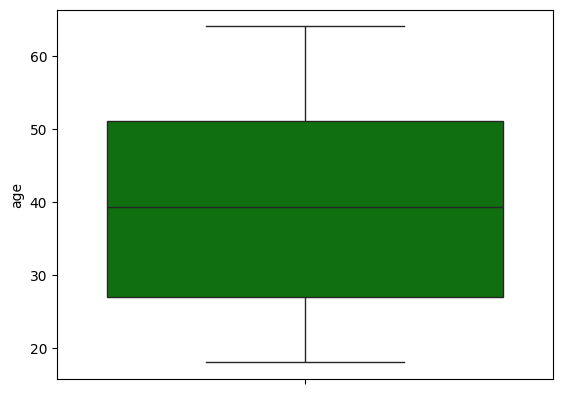

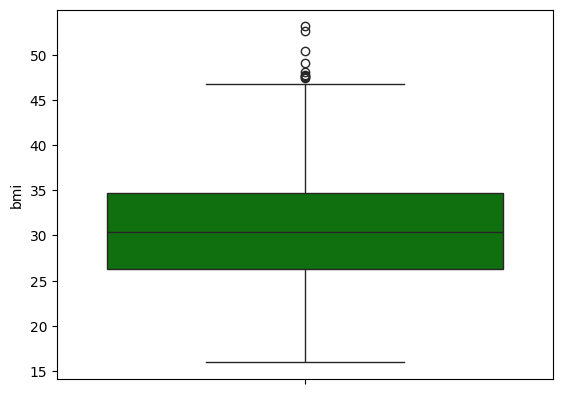

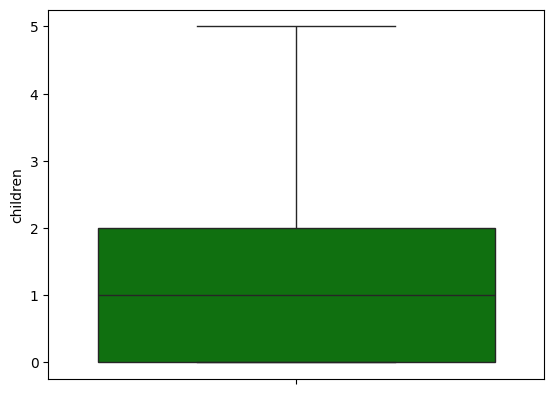

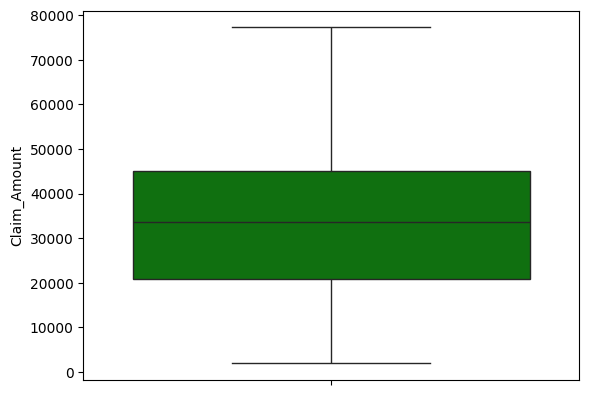

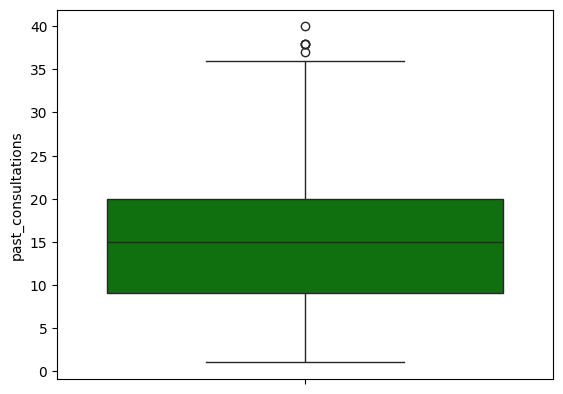

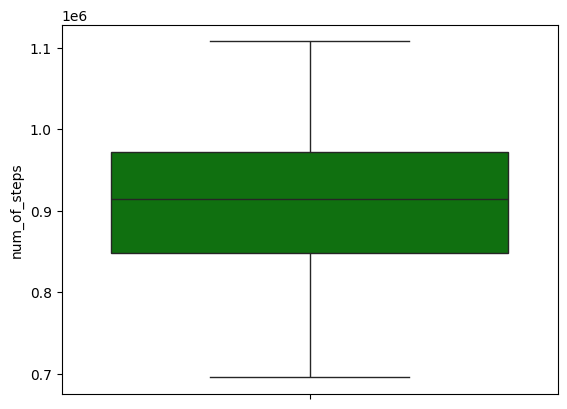

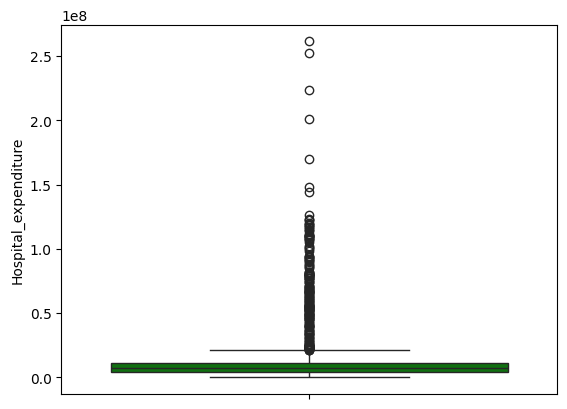

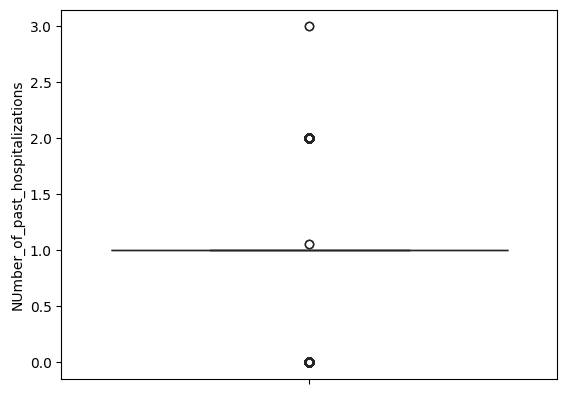

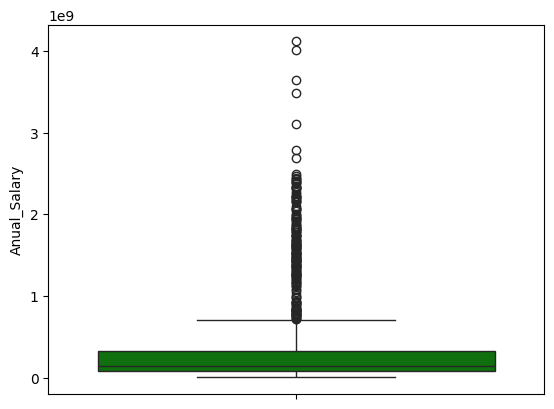

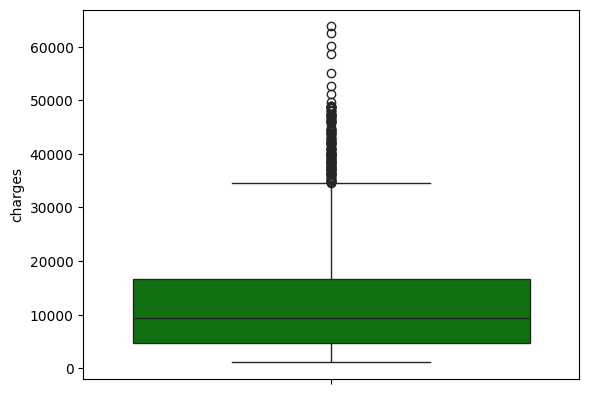

In [28]:
for col in df.columns:
  if df[col].dtype != 'object':
    sns.boxplot(df[col],color="green")
    plt.show()


In [ ]:
q1=df.quantile(0.25, numeric_only=True)
q3=df.quantile(0.75, numeric_only=True)
iqr=q3-q1

for col in df.columns:
    if df[col].dtype != 'object': # Process only numeric columns
        lower_bound = q1[col] - 1.5 * iqr[col]
        upper_bound = q3[col] + 1.5 * iqr[col]
        # Capping outliers
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
print("Outliers handled (capped) for numeric columns.")

In [32]:
#you should no tconsider target coloumn in outliiers elemenation coloum (ex=charges)
#  no box no outliers consider
outliers=['bmi','past_consultations','Hospital_expenditure',"Anual_Salary"]
for co in outliers:
  q1=df[co].quantile(0.25)
  q3=df[co].quantile(0.75)
  IQR=q3-q1
  LB=q1-1.5*IQR
  UB=q3+1.5*IQR
  df=df[(df[co] >=LB)& (df[co]<=UB)]

In [34]:
from sklearn.preprocessing import LabelEncoder
Le=LabelEncoder()
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=Le.fit_transform(df[col])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1025 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1025 non-null   float64
 1   sex                              1025 non-null   int64  
 2   bmi                              1025 non-null   float64
 3   children                         1025 non-null   float64
 4   smoker                           1025 non-null   int64  
 5   Claim_Amount                     1025 non-null   float64
 6   past_consultations               1025 non-null   float64
 7   num_of_steps                     1025 non-null   float64
 8   Hospital_expenditure             1025 non-null   float64
 9   NUmber_of_past_hospitalizations  1025 non-null   float64
 10  Anual_Salary                     1025 non-null   float64
 11  region                           1025 non-null   int64  
 12  charges                  

In [37]:
#know data ready for model buliding to predict charges based on 12 input value
#if data has no null values,duplicate,all in numerical,no outliers
x=df.drop('charges',axis=1)
y=df['charges']
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0


In [38]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1046,19107.77960
1048,19199.94400
1050,19350.36890
1062,19798.05455


In [39]:
#In the above problem satment understood
#cleaning done
#EDA done
#it is supervised as we know that output it charge
#know i am spliting the data as beause i want my model should understood the pattern based traning
#other part of data to testing weater my model understood pattern correctly

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
845,55.0,1,33.880,3.0,0,52155.958830,11.0,942142.0,7.683186e+06,1.0,1.969077e+08,2
138,21.0,0,35.720,0.0,0,29979.119780,21.0,783258.0,8.026176e+06,0.0,9.187363e+07,1
539,45.0,1,30.200,1.0,0,10853.283150,19.0,891489.0,1.548611e+06,1.0,6.963409e+07,3
500,37.0,1,22.705,3.0,0,38959.612550,6.0,881361.0,1.787167e+06,1.0,5.588399e+07,0
247,29.0,0,26.030,0.0,0,3830.100390,13.0,829344.0,7.297398e+06,1.0,5.803635e+07,1
...,...,...,...,...,...,...,...,...,...,...,...,...
708,50.0,0,30.115,1.0,0,14859.680110,11.0,912707.0,4.558918e+06,1.0,1.871882e+08,1
72,19.0,1,20.900,1.0,0,5987.151966,16.0,742921.0,4.803504e+06,0.0,1.125432e+07,3
107,19.0,0,37.430,0.0,0,47182.737540,13.0,777501.0,7.160947e+06,0.0,2.193514e+07,1
273,27.0,1,33.155,2.0,0,3768.603033,5.0,827853.0,1.004983e+07,1.0,7.027149e+07,1


In [42]:
x_test

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
532,43.0,0,35.640,1.0,0,15325.135260,8.0,888781.0,9032170.198,1.0,1.333644e+08,2
363,31.0,1,27.645,2.0,0,34741.334850,21.0,848272.0,6785795.914,1.0,9.201589e+07,0
451,32.0,0,37.145,3.0,0,28419.569750,16.0,864693.0,3487530.619,1.0,1.381901e+08,0
32,18.0,0,36.850,0.0,0,42510.441160,13.0,739413.0,3456345.420,0.0,7.155619e+07,2
627,49.0,1,22.515,0.0,0,49140.254220,10.0,898863.0,4776407.417,1.0,9.172299e+07,0
...,...,...,...,...,...,...,...,...,...,...,...,...
842,58.0,1,34.865,0.0,0,19343.067010,17.0,952115.0,9040238.101,1.0,2.125068e+08,0
805,56.0,0,25.650,0.0,0,29817.914130,9.0,948508.0,2054095.867,1.0,2.065395e+08,1
650,45.0,0,25.175,2.0,0,9920.458795,16.0,916392.0,4746549.469,1.0,8.737575e+07,0
408,39.0,0,41.800,0.0,0,50800.686870,15.0,878619.0,7760909.418,1.0,6.432577e+07,2


In [43]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
#testing
ans=model.predict(x_test)
ans

In [ ]:
#check good model or not trough accurency

In [47]:
from sklearn.metrics import r2_score#method used to check accurecy
r2_score(ans,y_test)*100  #good model

96.53086520564233

In [ ]:
#actual answe=119 predict=118 correct answer whith 1 error

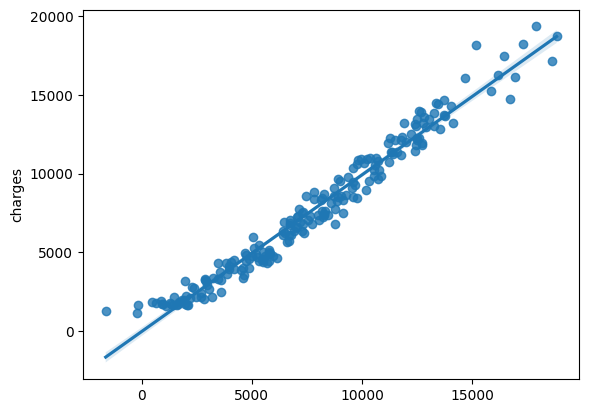

In [49]:
sns.regplot(x=ans,y=y_test)
plt.show()

In [64]:
#for example if one patient come and give the data and ask me what is charges i will xonvert that into data frame and give it to the model
han=[27, 1, 25.600, 0.0, 0, 30825.190070, 9.0, 821360.0, 5.923489e+06, 0.0, 7.490390e+07, 2]
han_da=pd.DataFrame(columns=x_train.columns)
han_da.loc[0]=han

In [66]:
ans=model.predict(han_da)
ans


array([5192.46906126])